# Visualizing Chaos


First, import necessery Python packages.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## Julia Set

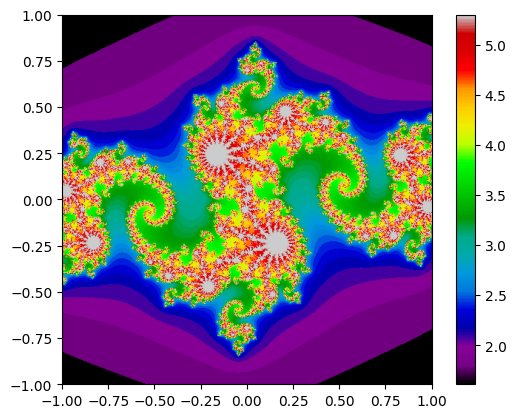

In [ ]:

def julia_set(c, xlim, ylim, res, max_iter):
    x = np.linspace(xlim[0], xlim[1], res[0])
    y = np.linspace(ylim[0], ylim[1], res[1])
    X, Y = np.meshgrid(x, y)
    img = np.zeros(X.shape, dtype=float)
    Z = X + 1j * Y
    for i in range(max_iter):
        mask = np.abs(Z) < 100
        Z[mask] = Z[mask]**2 + c
        img += mask        
    img = np.log(img + 1)
    return img

# Define parameters
c = -0.8 + 0.156j
#c=0*c
xlim = (-1., 1.)
ylim = (-1., 1.)
res = (500, 500)
max_iter = 200

# Generate Julia set and plot
img = julia_set(c, xlim, ylim, res, max_iter)
plt.imshow(img, extent=(xlim + ylim), cmap='nipy_spectral')
plt.colorbar()
plt.show()


## Mandelbrot set

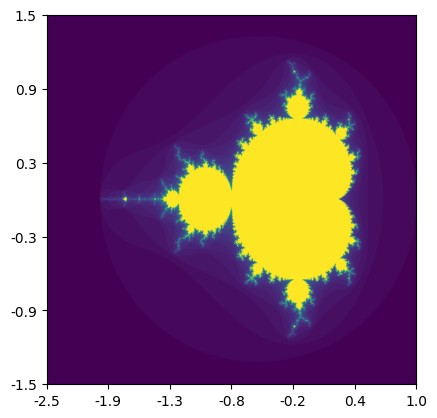

In [7]:
# Program 15c: The Mandelbrot set.
# See Figure 15.3.

xmin, xmax = -2.5, 1
ymin, ymax = -1.5, 1.5
xrange, yrange = xmax-xmin, ymax-ymin

def mandelbrot(h,w, max_iter=50):
     y, x = np.ogrid[ymin:ymax:h*1j, xmin:xmax:w*1j]
     c = x + y*1j
     z = c
     div_iter = max_iter + np.zeros(z.shape, dtype=int)

     for i in range(max_iter):
         z = z**2 + c
         div_test = z*np.conj(z) > 2**2
         div_num = div_test & (div_iter == max_iter)
         div_iter[div_num] = i
         z[div_test] = 2

     return div_iter  # Number of iterations to diverge

scale = 1000  # Amount of detail in the set

# Set the tick labels to the Argand plane
fig, ax = plt.subplots()
ax.imshow(mandelbrot(scale,scale))
xtick_labels = np.linspace(xmin, xmax, int(xrange / 0.5))
ax.set_xticks([(x-xmin) / xrange * scale for x in xtick_labels])
ax.set_xticklabels(['{:.1f}'.format(xtick) for xtick in xtick_labels])
ytick_labels = np.linspace(ymin, ymax, int(yrange / 0.5))
ax.set_yticks([-(y+ymin) / yrange * scale for y in ytick_labels])
ax.set_yticklabels(['{:.1f}'.format(ytick) for ytick in ytick_labels])
plt.show()

## Barnsley's fern

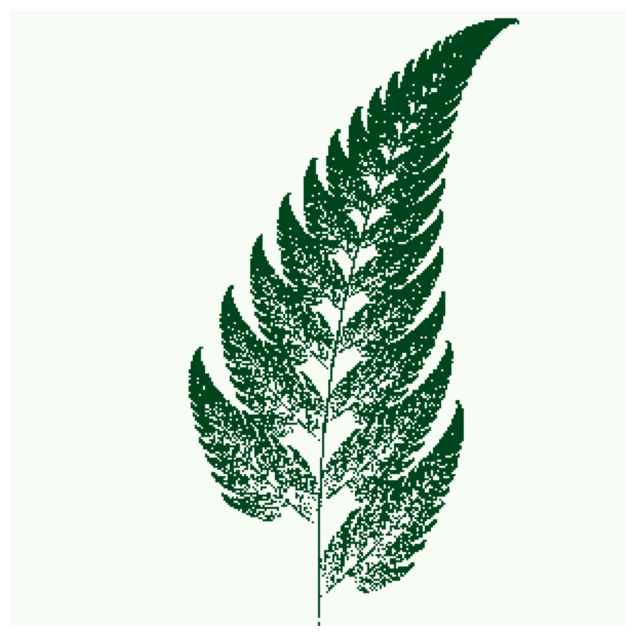

In [10]:
# Program 17c: Barnsley's fern.
# See Figure 17.7.

import matplotlib.cm as cm

# The transformation T
f1 = lambda x, y: (0.0, 0.2*y)
f2 = lambda x, y: (0.85*x + 0.05*y, -0.04*x + 0.85*y + 1.6)
f3 = lambda x, y: (0.2*x - 0.26*y, 0.23*x + 0.22*y + 1.6)
f4 = lambda x, y: (-0.15*x + 0.28*y, 0.26*x + 0.24*y + 0.44)
fs = [f1, f2, f3, f4]

num_points = 60000

width = height = 300
fern = np.zeros((width, height))

x, y = 0, 0
for i in range(num_points):
    # Choose a random transformation
    f = np.random.choice(fs, p=[0.01, 0.85, 0.07, 0.07])
    x, y = f(x,y)
    # Map (x,y) to pixel coordinates
    # Center the image
    cx, cy = int(width / 2 + x * width / 10), int(y * height / 10)
    fern[cy, cx] = 1

fig, ax=plt.subplots(figsize=(8,8))
plt.imshow(fern[::-1,:], cmap=cm.Greens)
ax.axis('off')
plt.show()


See also https://www.dynamicmath.xyz/mandelbrot-julia/